In [1]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    PrecisionRecallDisplay,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Create output folders if they don't exist
os.makedirs('splits', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

print('✓ Imports complete. Output folders ready.')

✓ Imports complete. Output folders ready.


In [ ]:
# ------------------------------------------------------------
# GOAL
# Detect fraudulent credit card transactions using ML.
# Compare model performance against environmental footprint (CO2e)
# to find the most responsible model for production use.
# ------------------------------------------------------------

# METRICS:
metrics_explanation = {
    'AUPRC': 'PRIMARY. Handles class imbalance correctly. Focuses on fraud detection performance.',
    'AUC-ROC': 'SECONDARY. Standard comparison metric across models.',
    'F1 Score': 'Harmonic mean of precision & recall. Good single-number summary.',
    'Precision': 'Of predicted frauds, how many were real? High = fewer false alarms.',
    'Recall': 'Of all real frauds, how many did we catch? High = fewer missed frauds.',
    'CO2e (kg)': 'Carbon cost of training + inference. Our environmental metric.',
    'Efficiency Score': 'Normalised AUPRC / Normalised CO2e. Our leaderboard formula.',
}

print('METRICS BEING USED:\n')
for metric, reason in metrics_explanation.items():
    print(f'  {metric:<20} {reason}')

# Constants used for carbon estimation throughout all notebooks
POWER_KW = 0.045            # Average laptop CPU draw in kW
CARBON_INTENSITY = 0.233    # UK grid carbon intensity (kg CO2 per kWh)

print(f'\nCARBON CONSTANTS:')
print(f'  Power assumption:      {POWER_KW} kW (laptop CPU)')
print(f'  UK Carbon Intensity:   {CARBON_INTENSITY} kg CO2/kWh')

METRICS BEING USED:

  AUPRC                PRIMARY. Handles class imbalance correctly. Focuses on fraud detection performance.
  AUC-ROC              SECONDARY. Standard comparison metric across models.
  F1 Score             Harmonic mean of precision & recall. Good single-number summary.
  Precision            Of predicted frauds, how many were real? High = fewer false alarms.
  Recall               Of all real frauds, how many did we catch? High = fewer missed frauds.
  CO2e (kg)            Carbon cost of training + inference. Our environmental metric.
  Efficiency Score     Normalised AUPRC / Normalised CO2e. Our leaderboard formula.

CARBON CONSTANTS:
  Power assumption:      0.045 kW (laptop CPU)
  UK Carbon Intensity:   0.233 kg CO2/kWh


Data Loading

In [3]:
# ------------------------------------------------------------
# Load the dataset
# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# ------------------------------------------------------------

df = pd.read_csv('data/creditcard.csv')

print(f'Shape:        {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn names: {list(df.columns)}')
print(f'\nFirst 3 rows:')
df.head(3)

Shape:        284,807 rows × 31 columns

Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 3 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Data Cleaning and Validation

In [4]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else '  ✓ None found.')

Missing values per column:
  ✓ None found.


In [5]:
# Check data types where all columns should be numeric (float64 or int64)
print('Data types:')
print(df.dtypes.value_counts())
print(f'\n  ✓ All numeric: {df.select_dtypes(include=np.number).shape[1] == df.shape[1]}')

Data types:
float64    30
int64       1
Name: count, dtype: int64

  ✓ All numeric: True


In [6]:
# Class distribution and imbalance ratio
fraud_count = df['Class'].sum()
total = len(df)
fraud_pct = fraud_count / total * 100

print('Class Distribution:')
print(f'  Genuine (0): {total - fraud_count:,}  ({100 - fraud_pct:.3f}%)')
print(f'  Fraud   (1): {fraud_count:,}    ({fraud_pct:.3f}%)')
print(f'\n  Imbalance ratio: 1 fraud per {int((total - fraud_count) / fraud_count)} genuine transactions')
print(f'  → This is why we use AUPRC as our primary metric, not accuracy.')

Class Distribution:
  Genuine (0): 284,315  (99.827%)
  Fraud   (1): 492    (0.173%)

  Imbalance ratio: 1 fraud per 577 genuine transactions
  → This is why we use AUPRC as our primary metric, not accuracy.


In [7]:
# Check and remove duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows found: {dupes:,}')

if dupes > 0:
    df = df.drop_duplicates()
    print(f'  → Removed. New shape: {df.shape}')
else:
    print('  ✓ No duplicates.')

print(f'\nFinal clean shape: {df.shape}')

Duplicate rows found: 1,081
  → Removed. New shape: (283726, 31)

Final clean shape: (283726, 31)


Exploratory Data Analysis (EDA)

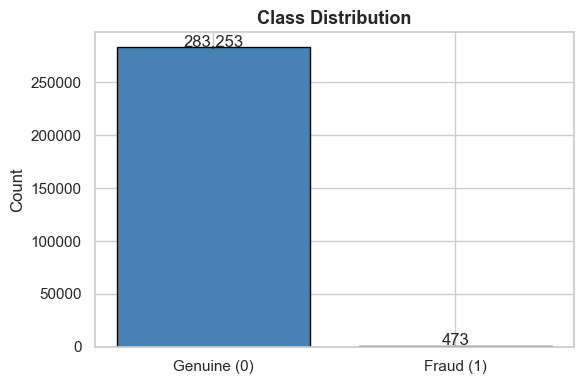

In [8]:
# Class imbalance visualisation
fig, ax = plt.subplots(figsize=(6, 4))
class_counts = df['Class'].value_counts()
ax.bar(['Genuine (0)', 'Fraud (1)'], class_counts.values,
       color=['steelblue', 'crimson'], edgecolor='black')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 1000, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('results/eda_class_distribution.png', dpi=150)
plt.show()

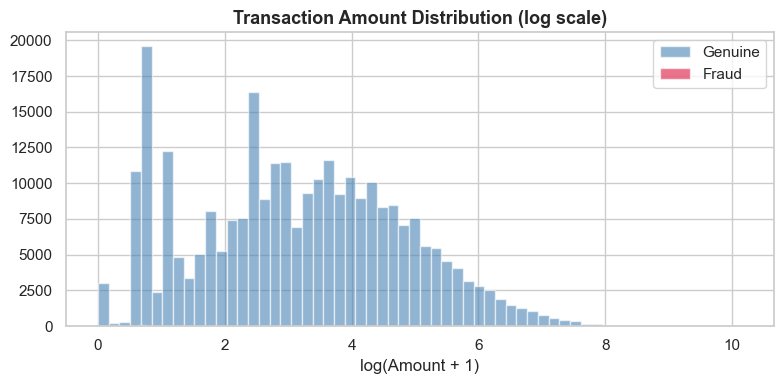

Amount stats by class:
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      283253.0   88.41  250.38  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.87  260.21  0.0  1.00   9.82  105.89   2125.87


In [9]:
# Transaction amount by class
# Log scale because Amount is heavily right-skewed
fig, ax = plt.subplots(figsize=(8, 4))
df[df['Class'] == 0]['Amount'].apply(np.log1p).hist(
    ax=ax, bins=60, alpha=0.6, color='steelblue', label='Genuine')
df[df['Class'] == 1]['Amount'].apply(np.log1p).hist(
    ax=ax, bins=60, alpha=0.6, color='crimson', label='Fraud')
ax.set_title('Transaction Amount Distribution (log scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('log(Amount + 1)')
ax.legend()
plt.tight_layout()
plt.savefig('results/eda_amount_distribution.png', dpi=150)
plt.show()

print('Amount stats by class:')
print(df.groupby('Class')['Amount'].describe().round(2))

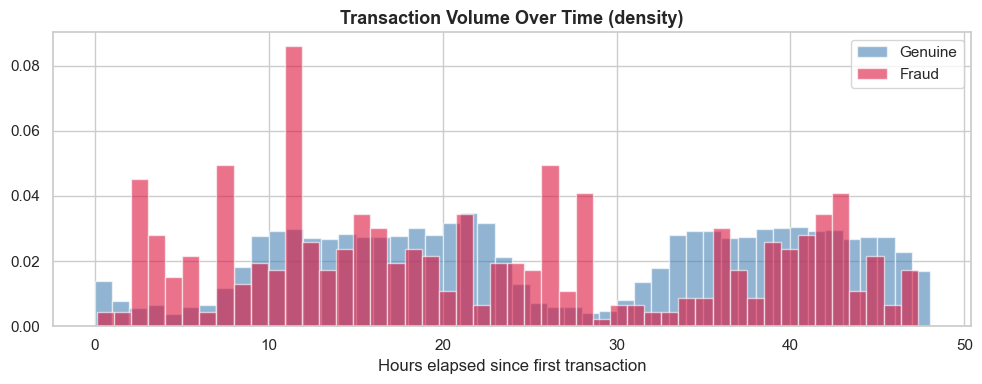

In [10]:
# Fraud patterns over time
# Time is in seconds — so we converted to hours for readability
df['Hour'] = df['Time'] / 3600

fig, ax = plt.subplots(figsize=(10, 4))
df[df['Class'] == 0]['Hour'].hist(
    ax=ax, bins=48, alpha=0.6, color='steelblue', label='Genuine', density=True)
df[df['Class'] == 1]['Hour'].hist(
    ax=ax, bins=48, alpha=0.6, color='crimson', label='Fraud', density=True)
ax.set_title('Transaction Volume Over Time (density)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hours elapsed since first transaction')
ax.legend()
plt.tight_layout()
plt.savefig('results/eda_time_distribution.png', dpi=150)
plt.show()

df = df.drop(columns=['Hour'])  # Clean up helper column

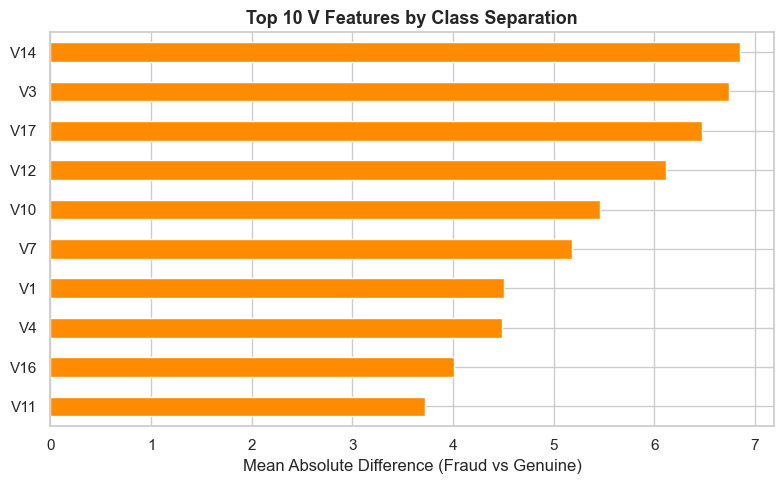

Top 10 most discriminative features:
V14    6.8476
V3     6.7425
V17    6.4742
V12    6.1127
V10    5.4609
V7     5.1864
V1     4.5117
V4     4.4830
V16    4.0088
V11    3.7224
dtype: float64

Top features: ['V14', 'V3', 'V17', 'V12', 'V10', 'V7', 'V1', 'V4', 'V16', 'V11']


In [11]:
# Which V features best separate fraud from genuine?
# This tells us which PCA components carry the most fraud signal
# Also useful for FinBERT because these are the features worth including in text

fraud_means = df[df['Class'] == 1].filter(like='V').mean()
genuine_means = df[df['Class'] == 0].filter(like='V').mean()
diff = (fraud_means - genuine_means).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
diff.head(10)[::-1].plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 10 V Features by Class Separation', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Absolute Difference (Fraud vs Genuine)')
plt.tight_layout()
plt.savefig('results/eda_top_features.png', dpi=150)
plt.show()

print('Top 10 most discriminative features:')
print(diff.head(10).round(4))

# Save top features list — useful for FinBERT text construction
top_features = diff.head(10).index.tolist()
print(f'\nTop features: {top_features}')

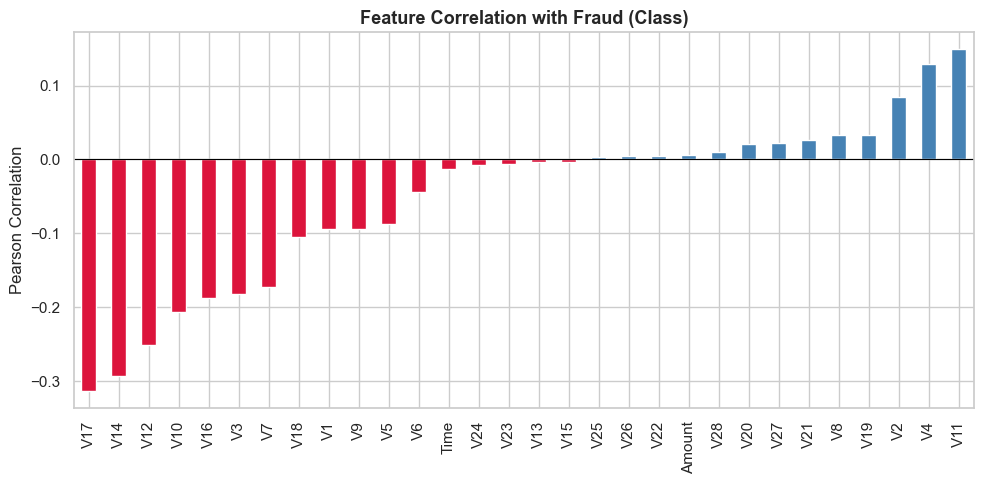

In [12]:
# Correlation of top features with Class label
v_cols = [f'V{i}' for i in range(1, 29)]
correlations = df[v_cols + ['Amount', 'Time', 'Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
correlations.plot(kind='bar', ax=ax, color=[
    'crimson' if x < 0 else 'steelblue' for x in correlations.values
])
ax.set_title('Feature Correlation with Fraud (Class)', fontsize=13, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('results/eda_correlations.png', dpi=150)
plt.show()

Feature Engineering
> V1–V28 are already PCA-transformed. Our task here is scaling Amount and Time, then splitting the data.

In [ ]:
# Scale Amount and Time
# These are the only raw (non-PCA) features.
# StandardScaler: zero mean, unit variance.
# Logistic Regression is sensitive to feature scale so doing this is essential.

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(columns=['Amount', 'Time'])

# Saved the scaler because it's needed if any model does inference on new data later
joblib.dump(scaler, 'models/scaler.pkl')

print('✓ Amount and Time scaled with StandardScaler.')
print(f'  Final feature columns: {list(df.columns)}')

✓ Amount and Time scaled with StandardScaler.
  Final feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Amount_scaled', 'Time_scaled']


In [14]:
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']

print(f'Feature matrix: {X.shape}')
print(f'Target:         {y.shape}  |  Fraud: {y.sum()} ({y.mean()*100:.3f}%)')

Feature matrix: (283726, 30)
Target:         (283726,)  |  Fraud: 473 (0.167%)


In [15]:
# Stratified train/test split
# stratify=y ensures the 0.172% fraud ratio is preserved in BOTH splits.
# random_state=42 — MUST stay fixed so all team members get identical splits.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,   # DO NOT CHANGE
    stratify=y
)

print('Train/Test Split (stratified):')
print(f'  X_train: {X_train.shape}  |  Fraud: {y_train.sum()} ({y_train.mean()*100:.3f}%)')
print(f'  X_test:  {X_test.shape}   |  Fraud: {y_test.sum()} ({y_test.mean()*100:.3f}%)')
print(f'\n  ✓ Fraud ratio preserved in both splits.')

Train/Test Split (stratified):
  X_train: (226980, 30)  |  Fraud: 378 (0.167%)
  X_test:  (56746, 30)   |  Fraud: 95 (0.167%)

  ✓ Fraud ratio preserved in both splits.



## Baseline Model: Logistic Regression

Why Logistic Regression?
- Simplest reasonable classifier — interpretable, fast, low carbon
- Sets the performance floor: any complex model should beat this to justify its cost
- `class_weight='balanced'` handles imbalance without resampling

In [16]:
# Train Logistic Regression
start_time = time.time()

lr_model = LogisticRegression(
    class_weight='balanced',  # handles class imbalance automatically
    max_iter=1000,            # default 100 often doesn't converge
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f'✓ Trained in {train_time:.2f} seconds.')

✓ Trained in 0.68 seconds.


In [17]:
# Evaluate
y_pred = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)[:, 1]  # fraud probability

auc_roc = roc_auc_score(y_test, y_proba)
auprc   = average_precision_score(y_test, y_proba)

print(f'  AUC-ROC:          {auc_roc:.4f}')
print(f'  AUPRC (PRIMARY):  {auprc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fraud']))

  AUC-ROC:          0.9658
  AUPRC (PRIMARY):  0.6720

Classification Report:
              precision    recall  f1-score   support

     Genuine       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



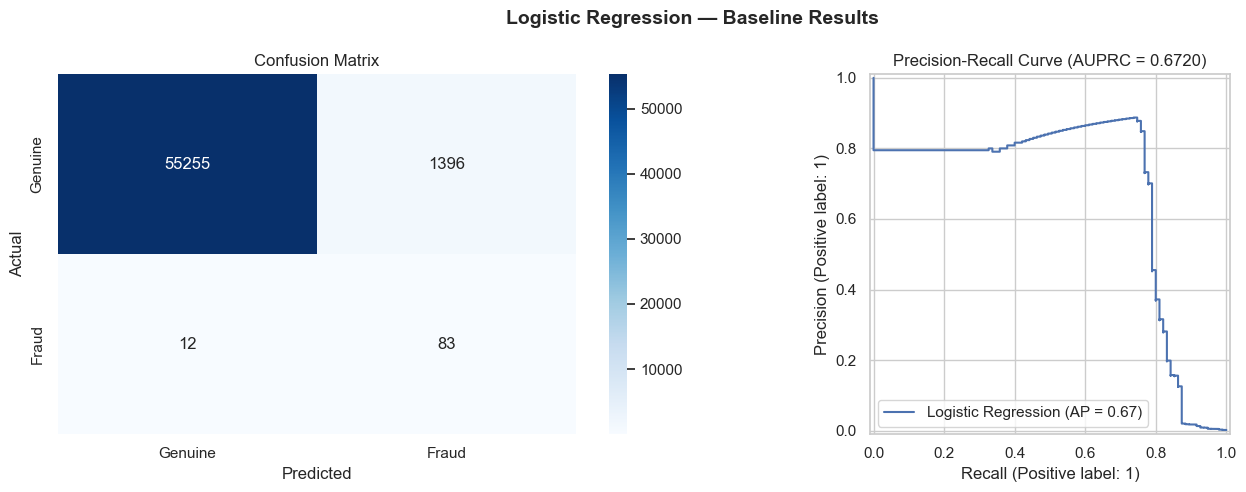

In [18]:
# Confusion matrix + Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Baseline Results', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Genuine', 'Fraud'],
            yticklabels=['Genuine', 'Fraud'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Precision-Recall curve — more informative than ROC for imbalanced data
PrecisionRecallDisplay.from_predictions(
    y_test, y_proba, ax=axes[1], name='Logistic Regression'
)
axes[1].set_title(f'Precision-Recall Curve (AUPRC = {auprc:.4f})')

plt.tight_layout()
plt.savefig('results/baseline_results.png', dpi=150)
plt.show()

In [19]:
# Carbon estimation
# Formula: kWh = Runtime (hours) × Power (kW)
#          CO2e = kWh × Carbon Intensity

train_hours = train_time / 3600
kwh_train   = train_hours * POWER_KW
co2_train   = kwh_train * CARBON_INTENSITY

# Inference cost per 1,000 predictions
infer_start = time.time()
_ = lr_model.predict_proba(X_test.iloc[:1000])
infer_time  = time.time() - infer_start
co2_infer   = (infer_time / 3600) * POWER_KW * CARBON_INTENSITY

print('Environmental Footprint:')
print(f'  Training time:              {train_time:.4f}s')
print(f'  Training energy:            {kwh_train:.8f} kWh')
print(f'  Training CO2e:              {co2_train:.8f} kg')
print(f'  Inference CO2e (1k preds):  {co2_infer:.8f} kg')

Environmental Footprint:
  Training time:              0.6770s
  Training energy:            0.00000846 kWh
  Training CO2e:              0.00000197 kg
  Inference CO2e (1k preds):  0.00000001 kg



## Saving All Outputs

All outputs saved here are used by every team member's notebook.

In [21]:
# Save train/test splits
joblib.dump((X_train, X_test, y_train, y_test), 'splits/data_splits.pkl')
print('✓ splits/data_splits.pkl saved')

# 7.2 — Save the trained Logistic Regression model
joblib.dump(lr_model, 'models/baseline_lr.pkl')
print('✓ models/baseline_lr.pkl saved')

# 7.3 — Save baseline metrics summary
# comparison.ipynb will load all of them and build the leaderboard
from sklearn.metrics import f1_score, precision_score, recall_score

summary = {
    'model': 'Logistic Regression (Baseline)',
    'auprc': round(float(auprc), 4),
    'auc_roc': round(float(auc_roc), 4),
    'f1': round(float(f1_score(y_test, y_pred)), 4),
    'precision': round(float(precision_score(y_test, y_pred)), 4),
    'recall': round(float(recall_score(y_test, y_pred)), 4),
    'train_time_s': round(train_time, 4),
    'co2_train_kg': round(co2_train, 10),
    'co2_infer_per_1k_kg': round(co2_infer, 10),
}

with open('results/summary_baseline.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✓ results/summary_baseline.json saved')
print('\nBaseline Summary:')
for k, v in summary.items():
    print(f'  {k:<30} {v}')

print('\n' + '='*60)
print('SHARED BASELINE COMPLETE.')
print('='*60)

✓ splits/data_splits.pkl saved
✓ models/baseline_lr.pkl saved
✓ results/summary_baseline.json saved

Baseline Summary:
  model                          Logistic Regression (Baseline)
  auprc                          0.672
  auc_roc                        0.9658
  f1                             0.1055
  precision                      0.0561
  recall                         0.8737
  train_time_s                   0.677
  co2_train_kg                   1.9717e-06
  co2_infer_per_1k_kg            1.49e-08

SHARED BASELINE COMPLETE.
